In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np


In [2]:
df=pd.read_csv('NYC.csv')

In [3]:
df.sample(5)

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
1242716,id2319645,2,2016-02-25 15:03:59,2016-02-25 15:04:07,1,-73.999702,40.745770,-73.998833,40.745449,N,8
896086,id3748667,1,2016-05-15 10:51:18,2016-05-15 10:56:25,1,-73.961075,40.760647,-73.959053,40.774811,N,307
1416122,id3714259,2,2016-03-18 20:45:17,2016-03-18 20:55:01,2,-73.990166,40.731983,-73.992004,40.741032,N,584
63663,id1101933,2,2016-05-11 20:51:31,2016-05-11 20:59:24,1,-73.955803,40.779324,-73.980324,40.773106,N,473
50461,id0244893,1,2016-03-26 09:45:27,2016-03-26 09:56:39,1,-73.978699,40.736664,-73.991127,40.750252,N,672


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 11 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1458644 non-null  str    
 1   vendor_id           1458644 non-null  int64  
 2   pickup_datetime     1458644 non-null  str    
 3   dropoff_datetime    1458644 non-null  str    
 4   passenger_count     1458644 non-null  int64  
 5   pickup_longitude    1458644 non-null  float64
 6   pickup_latitude     1458644 non-null  float64
 7   dropoff_longitude   1458644 non-null  float64
 8   dropoff_latitude    1458644 non-null  float64
 9   store_and_fwd_flag  1458644 non-null  str    
 10  trip_duration       1458644 non-null  int64  
dtypes: float64(4), int64(3), str(4)
memory usage: 122.4 MB


In [5]:
df.nunique()

id                    1458644
vendor_id                   2
pickup_datetime       1380222
dropoff_datetime      1380377
passenger_count            10
pickup_longitude        23047
pickup_latitude         45245
dropoff_longitude       33821
dropoff_latitude        62519
store_and_fwd_flag          2
trip_duration            7417
dtype: int64

In [6]:
df=df.drop('id',axis=1)

In [7]:
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])

In [8]:
df['pickup_datetime'].dtypes

dtype('<M8[us]')

In [9]:
df['pickup_datetime'].info()

<class 'pandas.Series'>
RangeIndex: 1458644 entries, 0 to 1458643
Series name: pickup_datetime
Non-Null Count    Dtype         
--------------    -----         
1458644 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 11.1 MB


In [10]:
df['pickup_hour']=df['pickup_datetime'].dt.hour

In [11]:
df['pickup_day']=df['pickup_datetime'].dt.day

In [12]:
df['pickup_month']=df['pickup_datetime'].dt.month

In [13]:
df['pickup_dayofweek']=df['pickup_datetime'].dt.dayofweek

In [14]:
df['pickup_year']=df['pickup_datetime'].dt.year

In [15]:
df['is_weekend'] = df['pickup_dayofweek'].isin([5, 6]).astype(int)

In [16]:
df.sample(5)

,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_dayofweek,pickup_year,is_weekend
767181,1,2016-05-01 17:44:59,2016-05-01 18:16:27,1,-74.001663,40.746140,-73.861931,40.767921,N,1888,17,1,5,6,2016,1
236607,2,2016-04-07 18:31:17,2016-04-07 18:45:38,1,-73.957108,40.769203,-73.976021,40.744652,N,861,18,7,4,3,2016,0
908654,1,2016-01-02 18:02:50,2016-01-02 18:12:45,1,-73.971992,40.762394,-73.995224,40.765118,N,595,18,2,1,5,2016,1
202701,2,2016-05-05 20:56:48,2016-05-05 21:03:27,6,-73.964958,40.791817,-73.948776,40.796734,N,399,20,5,5,3,2016,0
1072681,1,2016-05-25 22:30:53,2016-05-25 22:37:41,3,-73.989319,40.714092,-73.983711,40.730064,N,408,22,25,5,2,2016,0


In [17]:
df.drop(['pickup_datetime','dropoff_datetime','pickup_year'],axis=1,inplace=True)

In [18]:
df.sample(5)

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_dayofweek,is_weekend
883540,2,2,-73.962685,40.766857,-73.962944,40.774979,N,268,9,4,1,0,0
467201,2,1,-73.985641,40.746960,-73.968819,40.754139,N,451,1,16,4,5,1
212169,1,1,-74.002251,40.740265,-73.991417,40.754974,N,281,8,6,2,5,1
565554,2,1,-74.015907,40.715031,-73.935272,40.684109,N,2010,21,29,6,2,0
865936,1,1,-74.001358,40.741611,-73.992050,40.738132,N,360,11,29,2,0,0


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1458644 entries, 0 to 1458643
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1458644 non-null  int64  
 1   passenger_count     1458644 non-null  int64  
 2   pickup_longitude    1458644 non-null  float64
 3   pickup_latitude     1458644 non-null  float64
 4   dropoff_longitude   1458644 non-null  float64
 5   dropoff_latitude    1458644 non-null  float64
 6   store_and_fwd_flag  1458644 non-null  str    
 7   trip_duration       1458644 non-null  int64  
 8   pickup_hour         1458644 non-null  int32  
 9   pickup_day          1458644 non-null  int32  
 10  pickup_month        1458644 non-null  int32  
 11  pickup_dayofweek    1458644 non-null  int32  
 12  is_weekend          1458644 non-null  int64  
dtypes: float64(4), int32(4), int64(4), str(1)
memory usage: 122.4 MB


In [20]:
df['store_and_fwd_flag'].unique()

<StringArray>
['N', 'Y']
Length: 2, dtype: str

In [21]:
df['store_and_fwd_flag']=df['store_and_fwd_flag'].map({'N':0, 'Y':1})

In [22]:
df.sample(5)

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_dayofweek,is_weekend
550152,2,5,-73.981621,40.746201,-73.974869,40.758438,0,395,16,1,2,0,0
54448,1,2,-73.986160,40.764000,-73.984962,40.747231,0,1752,13,25,5,2,0
1185705,2,5,-73.957054,40.780392,-73.937119,40.807690,0,506,23,14,1,3,0
706101,1,1,-73.976418,40.683582,-73.970856,40.681793,0,126,20,19,2,4,0
1009087,2,2,-73.980873,40.769619,-73.954323,40.764252,0,503,5,3,5,1,0


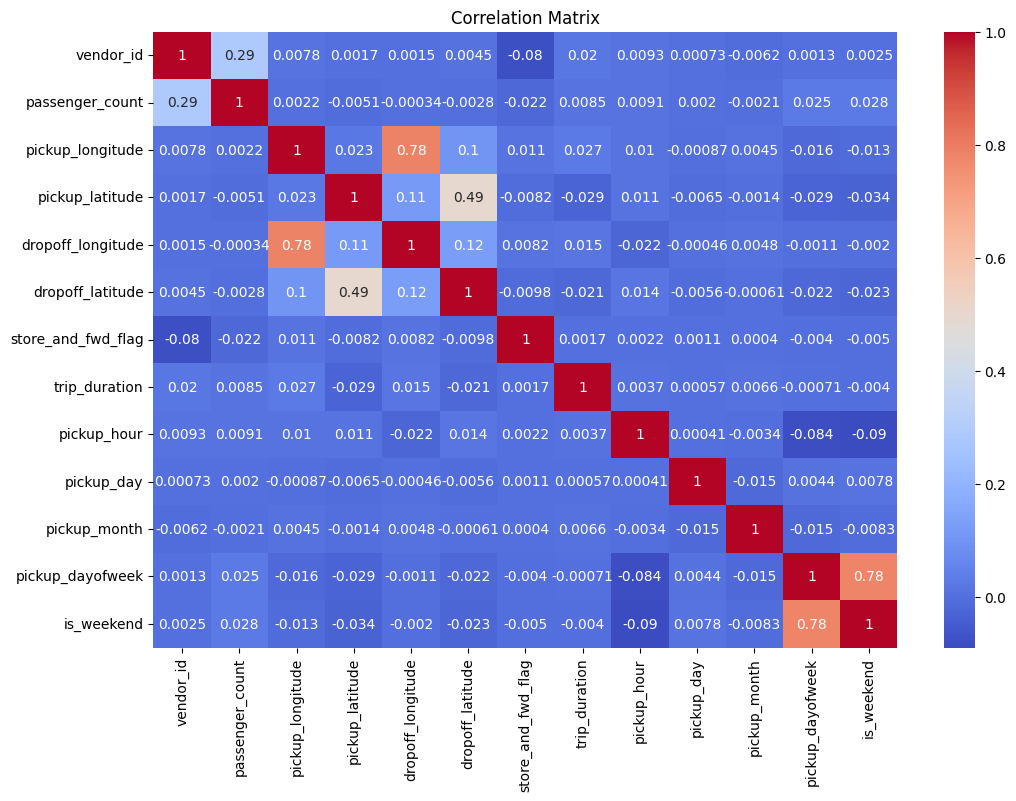

In [23]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [24]:
df.corr(numeric_only=True)['trip_duration'].sort_values(ascending=False)

trip_duration         1.000000
pickup_longitude      0.026542
vendor_id             0.020304
dropoff_longitude     0.014678
passenger_count       0.008471
pickup_month          0.006607
pickup_hour           0.003690
store_and_fwd_flag    0.001724
pickup_day            0.000566
pickup_dayofweek     -0.000708
is_weekend           -0.004009
dropoff_latitude     -0.020677
pickup_latitude      -0.029204
Name: trip_duration, dtype: float64

<Axes: xlabel='trip_duration', ylabel='Count'>

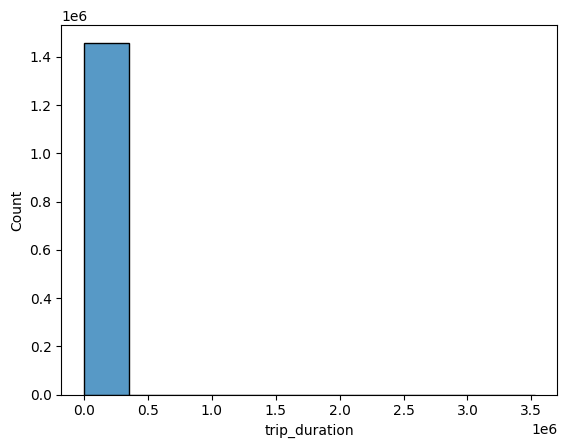

In [25]:
sns.histplot(df['trip_duration'],bins=10)

In [26]:
df['trip_duration'].describe()

count    1.458644e+06
mean     9.594923e+02
std      5.237432e+03
min      1.000000e+00
25%      3.970000e+02
50%      6.620000e+02
75%      1.075000e+03
max      3.526282e+06
Name: trip_duration, dtype: float64

In [27]:
df['trip_duration'].sort_values(ascending=False).head(10)

978383     3526282
924150     2227612
680594     2049578
355003     1939736
1234291      86392
295382       86391
73816        86390
59891        86387
1360439      86385
753765       86379
Name: trip_duration, dtype: int64

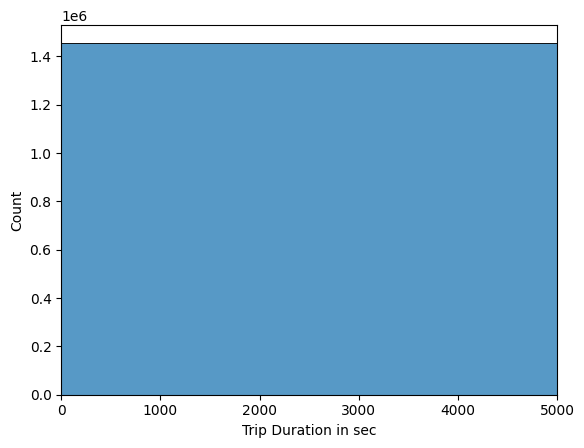

In [28]:
sns.histplot(df['trip_duration'],bins=50)
plt.xlim(0,5000)
plt.xlabel('Trip Duration in sec')
plt.ylabel('Count')
plt.show()


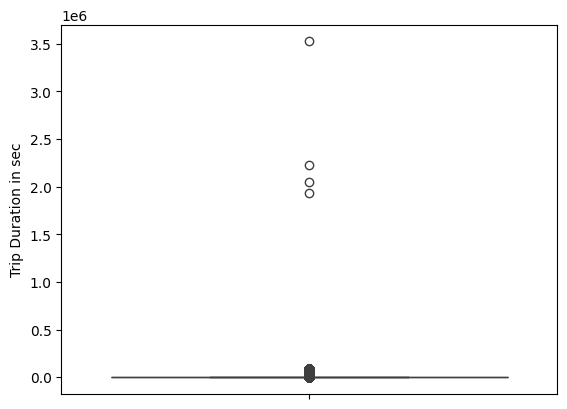

In [29]:
sns.boxplot(y=df['trip_duration'])
plt.ylabel('Trip Duration in sec')
plt.show()

In [30]:
df['trip_duration'].quantile([0.01, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999])

0.010       87.000
0.250      397.000
0.500      662.000
0.750     1075.000
0.950     2104.000
0.990     3440.000
0.999    85128.357
Name: trip_duration, dtype: float64

In [31]:
df.sort_values('trip_duration', ascending=False).head(20)

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_dayofweek,is_weekend
978383,1,1,-73.783905,40.648632,-73.978271,40.750202,0,3526282,22,13,2,5,1
924150,1,1,-73.983788,40.742325,-73.985489,40.727676,0,2227612,6,5,1,1,0
680594,1,2,-73.921677,40.735252,-73.984749,40.759979,0,2049578,22,13,2,5,1
355003,1,1,-73.789650,40.643559,-73.956810,40.773087,0,1939736,0,5,1,1,0
1234291,2,2,-73.794525,40.644825,-73.991051,40.755573,0,86392,23,15,2,0,0
295382,2,1,-73.781952,40.644688,-73.993874,40.745926,0,86391,13,31,5,1,0
73816,2,1,-73.996010,40.753220,-73.979027,40.740601,0,86390,0,6,5,4,0
59891,2,1,-73.992279,40.749729,-73.962524,40.800770,0,86387,16,30,6,3,0
1360439,2,1,-73.782089,40.644806,-73.985016,40.666828,0,86385,16,23,6,3,0
753765,2,4,-74.006111,40.734680,-73.958809,40.815449,0,86379,22,17,5,1,0


In [32]:
df.columns

Index(['vendor_id', 'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration', 'pickup_hour', 'pickup_day', 'pickup_month',
       'pickup_dayofweek', 'is_weekend'],
      dtype='str')

In [33]:
df[df['trip_duration'] > 86400].shape

(4, 13)

In [34]:
df[df['trip_duration'] > 86400].sort_values(
    'trip_duration',
    ascending=False
).head(20)

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration,pickup_hour,pickup_day,pickup_month,pickup_dayofweek,is_weekend
978383,1,1,-73.783905,40.648632,-73.978271,40.750202,0,3526282,22,13,2,5,1
924150,1,1,-73.983788,40.742325,-73.985489,40.727676,0,2227612,6,5,1,1,0
680594,1,2,-73.921677,40.735252,-73.984749,40.759979,0,2049578,22,13,2,5,1
355003,1,1,-73.789650,40.643559,-73.956810,40.773087,0,1939736,0,5,1,1,0


In [35]:
print("Total rows:", len(df))
print("Trips > 24 hours:", (df['trip_duration'] > 86400).sum())
print("Percentage:", (df['trip_duration'] > 86400).mean() * 100)

Total rows: 1458644
Trips > 24 hours: 4
Percentage: 0.0002742272960365929


In [36]:
df = df[df['trip_duration'] <= 86400].copy()

In [37]:
print(len(df))
print(df['trip_duration'].max())

1458640
86392


<Axes: xlabel='passenger_count', ylabel='trip_duration'>

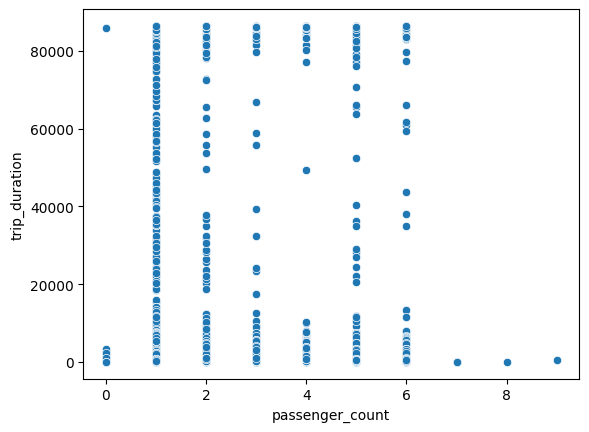

In [38]:
sns.scatterplot(x='passenger_count', y='trip_duration', data=df)

<Axes: xlabel='pickup_hour'>

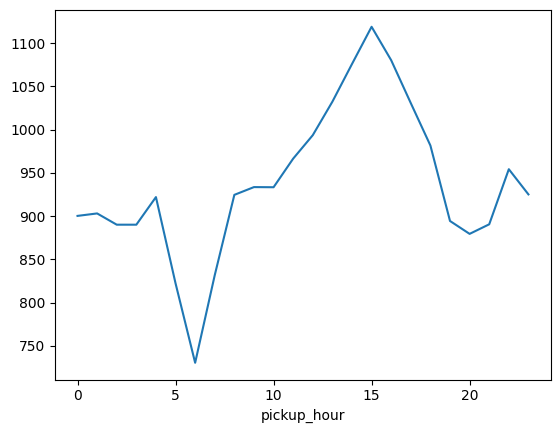

In [39]:
df.groupby('pickup_hour')['trip_duration'].mean().plot(kind='line')

<Axes: xlabel='pickup_dayofweek'>

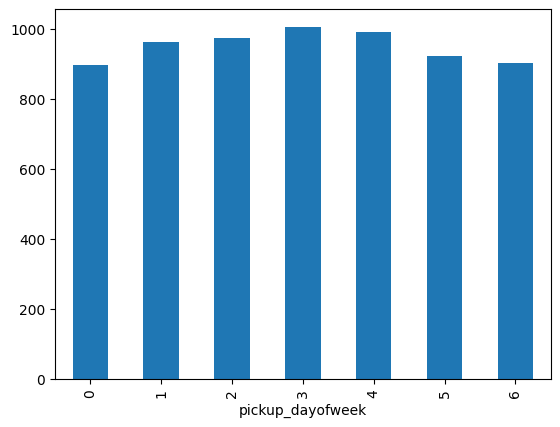

In [40]:
df.groupby('pickup_dayofweek')['trip_duration'].mean().plot(kind='bar')

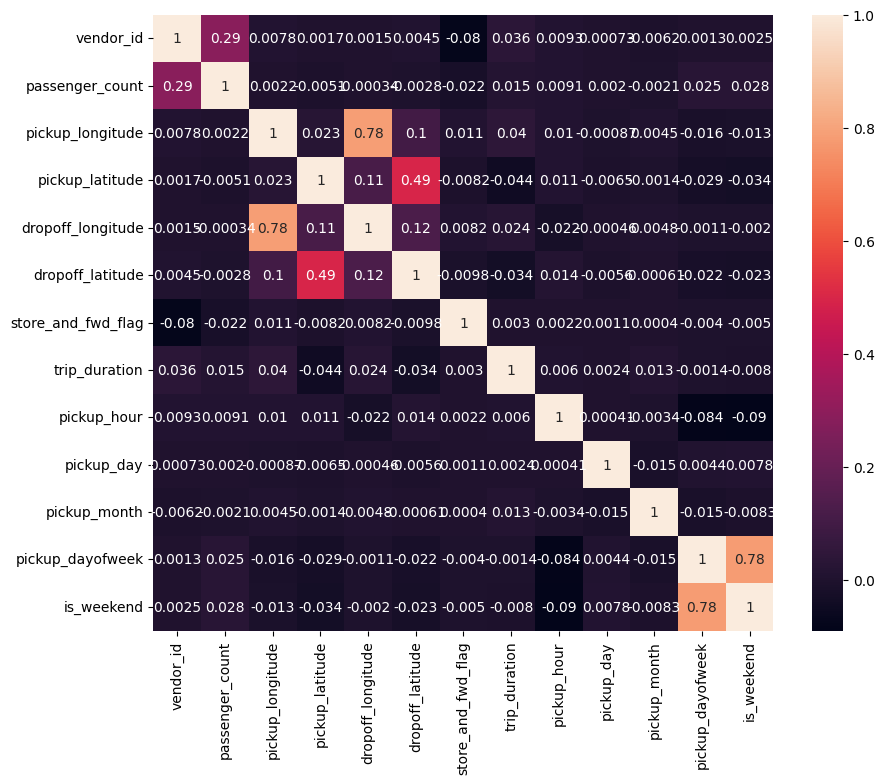

In [41]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

<Axes: ylabel='trip_duration'>

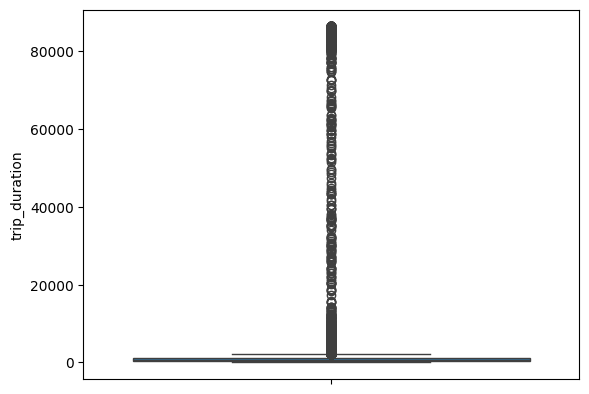

In [42]:
sns.boxplot(y=df['trip_duration'])

In [43]:
print((df['trip_duration'] > 80000).sum())

1895


In [44]:
print(df[df['trip_duration'] > 80000]['trip_duration'].describe())

count     1895.000000
mean     85498.207388
std       1094.193840
min      80089.000000
25%      85239.000000
50%      85937.000000
75%      86229.000000
max      86392.000000
Name: trip_duration, dtype: float64


In [45]:
# print((df['trip_duration'] > 80000).mean() * 100)

In [46]:
# print((df['trip_duration'] >= 86300).sum())

In [47]:
df['trip_duration'].max()

np.int64(86392)

In [48]:
df.isnull().sum()

vendor_id             0
passenger_count       0
pickup_longitude      0
pickup_latitude       0
dropoff_longitude     0
dropoff_latitude      0
store_and_fwd_flag    0
trip_duration         0
pickup_hour           0
pickup_day            0
pickup_month          0
pickup_dayofweek      0
is_weekend            0
dtype: int64

In [49]:
df.duplicated().sum()

np.int64(7)

In [50]:
df.drop_duplicates(inplace=True)

In [51]:
df.duplicated().sum()

np.int64(0)

In [52]:
df.info()

<class 'pandas.DataFrame'>
Index: 1458633 entries, 0 to 1458643
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   vendor_id           1458633 non-null  int64  
 1   passenger_count     1458633 non-null  int64  
 2   pickup_longitude    1458633 non-null  float64
 3   pickup_latitude     1458633 non-null  float64
 4   dropoff_longitude   1458633 non-null  float64
 5   dropoff_latitude    1458633 non-null  float64
 6   store_and_fwd_flag  1458633 non-null  int64  
 7   trip_duration       1458633 non-null  int64  
 8   pickup_hour         1458633 non-null  int32  
 9   pickup_day          1458633 non-null  int32  
 10  pickup_month        1458633 non-null  int32  
 11  pickup_dayofweek    1458633 non-null  int32  
 12  is_weekend          1458633 non-null  int64  
dtypes: float64(4), int32(4), int64(5)
memory usage: 133.5 MB


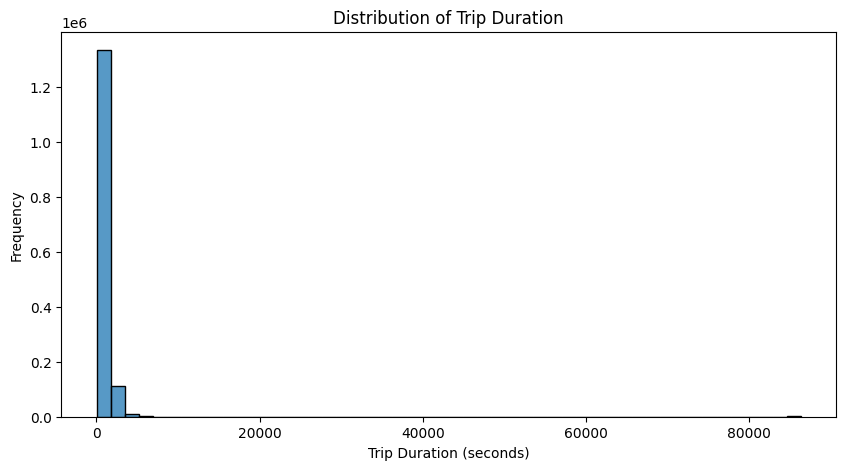

In [53]:
plt.figure(figsize=(10,5))
sns.histplot(df['trip_duration'], bins=50)
plt.xlabel('Trip Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Trip Duration')
plt.show()

In [54]:
df = df[df['trip_duration'] <= 86400].copy()

In [55]:
df.drop_duplicates(inplace=True)

In [56]:
# import numpy as np

# def haversine_distance(lat1, lon1, lat2, lon2):
#     R = 6371  # Earth radius in kilometers

#     lat1 = np.radians(lat1)
#     lon1 = np.radians(lon1)
#     lat2 = np.radians(lat2)
#     lon2 = np.radians(lon2)

#     dlat = lat2 - lat1
#     dlon = lon2 - lon1

#     a = (
#         np.sin(dlat / 2)**2
#         + np.cos(lat1) * np.cos(lat2)
#         * np.sin(dlon / 2)**2
#     )

#     c = 2 * np.arcsin(np.sqrt(a))

#     return R * c

In [57]:
# nyc_bounds = {'lon': (-74.05, -73.70), 'lat': (40.55, 40.95)}
# df = df[
#     df['pickup_longitude'].between(*nyc_bounds['lon']) &
#     df['pickup_latitude'].between(*nyc_bounds['lat']) &
#     df['dropoff_longitude'].between(*nyc_bounds['lon']) &
#     df['dropoff_latitude'].between(*nyc_bounds['lat'])
# ]

In [58]:
# df['distance_km'] = haversine_distance(
#     df['pickup_latitude'],
#     df['pickup_longitude'],
#     df['dropoff_latitude'],
#     df['dropoff_longitude']
# )

In [59]:
# y_log = np.log1p(df['trip_duration'])
# # fit on y_log, then np.expm1(pred) to convert back for reporting RMSE/MAE in seconds

In [60]:
# X = df.drop('trip_duration', axis=1)
# y = df['trip_duration']

In [61]:
# 1. Haversine distance function (restored, not commented out)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 2. Filter to realistic NYC coordinates FIRST
nyc_bounds = {'lon': (-74.05, -73.70), 'lat': (40.55, 40.95)}
df = df[
    df['pickup_longitude'].between(*nyc_bounds['lon']) &
    df['pickup_latitude'].between(*nyc_bounds['lat']) &
    df['dropoff_longitude'].between(*nyc_bounds['lon']) &
    df['dropoff_latitude'].between(*nyc_bounds['lat'])
].copy()

# 3. THEN compute distance, on the cleaned coordinates
df['distance_km'] = haversine_distance(
    df['pickup_latitude'], df['pickup_longitude'],
    df['dropoff_latitude'], df['dropoff_longitude']
)

# sanity check — should now be capped at realistic NYC distances
print(df['distance_km'].describe())

# 4. Log-transform the target (actually use it this time)
X = df.drop('trip_duration', axis=1)
y = np.log1p(df['trip_duration'])   # <-- train on log(1+duration), not raw seconds

print(X.shape, y.shape)

count    1.453916e+06
mean     3.389804e+00
std      3.815461e+00
min      0.000000e+00
25%      1.230705e+00
50%      2.088125e+00
75%      3.849740e+00
max      3.694970e+01
Name: distance_km, dtype: float64
(1453916, 13) (1453916,)


In [62]:
print(X.shape)
print(y.shape)

(1453916, 13)
(1453916,)


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [64]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

In [65]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [66]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [67]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, min_samples_leaf=20, random_state=42),
    "Random Forest Regressor": RandomForestRegressor(),
    "Graident BoostRegressor":GradientBoostingRegressor(),
    "Xgboost Regressor":XGBRegressor()
   
}

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.5935
- Mean Absolute Error: 0.4298
- R2 Score: 0.4377
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.5952
- Mean Absolute Error: 0.4297
- R2 Score: 0.4362


Lasso
Model performance for Training set
- Root Mean Squared Error: 0.7915
- Mean Absolute Error: 0.6029
- R2 Score: 0.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.7927
- Mean Absolute Error: 0.6030
- R2 Score: -0.0000


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.5935
- Mean Absolute Error: 0.4298
- R2 Score: 0.4377
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.5952
- Mean Absolute Error: 0.4297
- R2 Score: 0.4362


Decision Tree
Model performance for Training set
- Root Mean Squared Error: 0.4434
- Mean Absolute Error: 0.3010
- R2 Score: 0.6862
------------------------------

In [68]:
rf_params = {"max_depth": [5, 8, 15, None, 10],
             "max_features": [5, 7, "auto", 8],
             "min_samples_split": [2, 8, 15, 20],
             "n_estimators": [100, 200, 500, 1000]}

xgboost_params = {"learning_rate": [0.1, 0.01],
                  "max_depth": [5, 8, 12, 20, 30],
                  "n_estimators": [100, 200, 300],
                  "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4]}

In [69]:
randomcv_models = [
                   ("RF", RandomForestRegressor(), rf_params),
                   ("XGboost",XGBRegressor(),xgboost_params)
                   
                   ]

In [70]:
##Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV

model_param = {}
for name, model, params in randomcv_models:
    random = RandomizedSearchCV(estimator=model,
                                   param_distributions=params,
                                   n_iter=30,
                                   cv=3,
                                   verbose=2,
                                   n_jobs=-1)
    random.fit(X_train, y_train)
    model_param[name] = random.best_params_

for model_name in model_param:
    print(f"---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])

Fitting 3 folds for each of 30 candidates, totalling 90 fits


d:\ml_projects_git_hub\mlenv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
40 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "d:\ml_projects_git_hub\mlenv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\ml_projects_git_hub\mlenv\Lib\site-packages\sklearn\base.py", line 1393, in wrapper
    estimator._validate_params()
  File "d:\ml_projects_git_hub\mlenv\Lib\site-packages\sklearn\base.py", line 554, in _validate_params
    validate_parameter_constraints(
  File "d:\ml_projects_git_hub\mlenv

Fitting 3 folds for each of 30 candidates, totalling 90 fits


d:\ml_projects_git_hub\mlenv\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
35 fits failed out of a total of 90.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "d:\ml_projects_git_hub\mlenv\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "d:\ml_projects_git_hub\mlenv\Lib\site-packages\xgboost\core.py", line 751, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "d:\ml_projects_git_hub\mlenv\Lib\site-packages\xgboost\sklearn.py", line 1368, in fit
    self._Booster = train(
                    ^^^^^^
  File "d

---------------- Best Params for RF -------------------
{'n_estimators': 100, 'min_samples_split': 15, 'max_features': 7, 'max_depth': None}
---------------- Best Params for XGboost -------------------
{'n_estimators': 200, 'max_depth': 12, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [72]:
## Retraining the models with best parameters
models = {
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, min_samples_split=15, max_features=7, max_depth=None, 
                                                     n_jobs=-1),
     "Xgboost Regressor":XGBRegressor(n_estimators= 200,learning_rate=0.1,
                                     max_depth=12,colsample_bytree=0.8,tree_method="hist", device="cuda")
    
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)
    
    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    
    print('='*35)
    print('\n')

Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 0.2700
- Mean Absolute Error: 0.1675
- R2 Score: 0.8836
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.4005
- Mean Absolute Error: 0.2520
- R2 Score: 0.7447




d:\ml_projects_git_hub\mlenv\Lib\site-packages\xgboost\core.py:751: UserWarning: [17:53:08] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Xgboost Regressor
Model performance for Training set
- Root Mean Squared Error: 0.2869
- Mean Absolute Error: 0.1917
- R2 Score: 0.8686
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.3928
- Mean Absolute Error: 0.2383
- R2 Score: 0.7544




In [83]:
y_pred = models["Xgboost Regressor"].predict(X_test)

In [84]:
y_pred = np.expm1(models["Xgboost Regressor"].predict(X_test))

In [ ]:
sample = pd.DataFrame({
    'vendor_id': [1],
    'passenger_count': [1],
    'pickup_longitude': [-73.9857],
    'pickup_latitude': [40.7484],
    'dropoff_longitude': [-73.9776],
    'dropoff_latitude': [40.7527],
    'store_and_fwd_flag': [0],
    'pickup_hour': [18],
    'pickup_day': [15],
    'pickup_month': [6],
    'pickup_dayofweek': [4],
    'is_weekend': [0],
    'distance_km': [1.2]
})

# scale it the same way training data was scaled
sample_scaled = scaler.transform(sample)

# predict (log-space) and convert back to seconds
pred_log = models["Xgboost Regressor"].predict(sample_scaled)
pred_seconds = np.expm1(pred_log)

print(f"Predicted trip duration: {pred_seconds[0]:.1f} seconds (~{pred_seconds[0]/60:.1f} min)")

Predicted trip duration: 577.4 seconds (~9.6 min)


In [87]:
import joblib
joblib.dump(models["Xgboost Regressor"], 'xgb_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

# later
model = joblib.load('xgb_model.pkl')
scaler = joblib.load('scaler.pkl')